# cedikit demo

From messy phone numbers and raw MoMo SMS to a clean ledger, charts and fraud warnings.
All data here is synthetic or anonymised (see `examples/make_demo_data.py`).

In [1]:
%matplotlib inline
import csv
from datetime import date

import pandas as pd

import cedikit
import cedikit.integrations.pandas_accessor  # registers df[col].cedikit
from cedikit import Cedi, fees, fraud, money, phone
from cedikit.ledger import Ledger

cedikit.__version__

'1.0.0'

## 1. Messy phone numbers

500 customer numbers typed every way people type them.

In [2]:
customers = pd.read_csv("../examples/customers.csv", dtype=str)
customers.head(8)

,name,phone,town
0,Esi Tetteh,+233 0545881399,Sunyani
1,Abena Mensah,+233269730911,Sunyani
2,Adwoa Owusu,00233265364556,Ho
3,Kojo Mensah,+233 0501884472,Sunyani
4,Akosua Ansah,+233505761698,Sunyani
5,Yaa Boateng,0266846978,Sunyani
6,Efua Owusu,055 081 9672,Ho
7,Afia Ofori,00233267848648,Sunyani


In [3]:
customers["e164"] = customers["phone"].cedikit.normalise()
customers["network"] = customers["phone"].cedikit.likely_network()
print(phone.clean_column(customers["phone"]))
customers.head(8)

500 numbers: 36 valid, 434 fixed, 30 invalid


,name,phone,town,e164,network
0,Esi Tetteh,+233 0545881399,Sunyani,+233545881399,MTN
1,Abena Mensah,+233269730911,Sunyani,+233269730911,AT
2,Adwoa Owusu,00233265364556,Ho,+233265364556,AT
3,Kojo Mensah,+233 0501884472,Sunyani,+233501884472,TELECEL
4,Akosua Ansah,+233505761698,Sunyani,+233505761698,TELECEL
5,Yaa Boateng,0266846978,Sunyani,+233266846978,AT
6,Efua Owusu,055 081 9672,Ho,+233550819672,MTN
7,Afia Ofori,00233267848648,Sunyani,+233267848648,AT


In [4]:
customers["network"].value_counts(dropna=False)

network
MTN        212
AT         172
TELECEL     86
None        30
Name: count, dtype: int64

## 2. Money: why floats are dangerous

In [5]:
0.1 + 0.2

0.30000000000000004

In [6]:
print(sum([Cedi("0.10"), Cedi("0.20")]))
print(money.parse("GH₵1.2k"))
print(money.to_words("1200.50"))

GH₵ 0.30
1200.00
One thousand two hundred Ghana cedis and fifty pesewas


In [7]:
try:
    money.format(1200.5)
except cedikit.CediTypeError as exc:
    print(exc)

use Decimal, int or str for money, not float - floats cannot represent pesewas exactly (0.1 + 0.2 == 0.30000000000000004)


## 3. A month of MoMo SMS → ledger

In [8]:
with open("../examples/inbox.csv", encoding="utf-8") as fh:
    messages = list(csv.DictReader(fh))
print(len(messages), "messages")
print(messages[0]["text"])

110 messages
Payment received for GHS 50.00 from ABENA MENSAH Current Balance: GHS 260.40 . Available Balance: GHS 260.40. Reference: Rice. Transaction ID: 51171267101. TRANSACTION FEE: 0.00


In [9]:
ledger = Ledger.from_messages(messages).categorise()
print(ledger.summary())
print(len(ledger.notices), "notices;", len(ledger.balance_gaps()), "balance gaps")

106 transactions (02 Sep 2026 to 01 Oct 2026)
  Money in:  GH₵ 5,945.00
  Money out: GH₵ 4,580.00
  Fees:      GH₵ 5.46
  Taxes:     GH₵ 0.00
  Net:       GH₵ 1,359.54
  Last MTN balance: GH₵ 1,417.40
  Last TELECEL balance: GH₵ 187.64
4 notices; 0 balance gaps


In [10]:
pd.Series({k: float(v) for k, v in ledger.category_totals().items()}, name="GHS")

sales & money received    5545.0
payments & supplies       3699.0
cash withdrawal            400.0
cash deposit               400.0
money sent                 291.0
loan repayment             150.0
airtime & data              40.0
Name: GHS, dtype: float64

In [11]:
pd.DataFrame(
    [(p.start, p.inflow, p.outflow, p.net) for p in ledger.cash_flow("week")],
    columns=["week", "in", "out", "net"],
)

,week,in,out,net
0,2026-08-31,765.00,496.00,268.76
1,2026-09-07,1790.00,1182.00,606.91
2,2026-09-14,1340.00,1271.00,67.46
3,2026-09-21,1355.00,1381.00,-27.59
4,2026-09-28,695.00,250.00,444.00


In [12]:
[(c.name, c.count, c.total) for c in ledger.top_counterparties(3, by="value")]

[('KUMASI WHOLESALE PROVISIONS', 4, Decimal('3699.00')),
 ('ABENA MENSAH', 13, Decimal('875.00')),
 ('ADOM MOBILE MONEY ENTERPRISE', 6, Decimal('800.00'))]

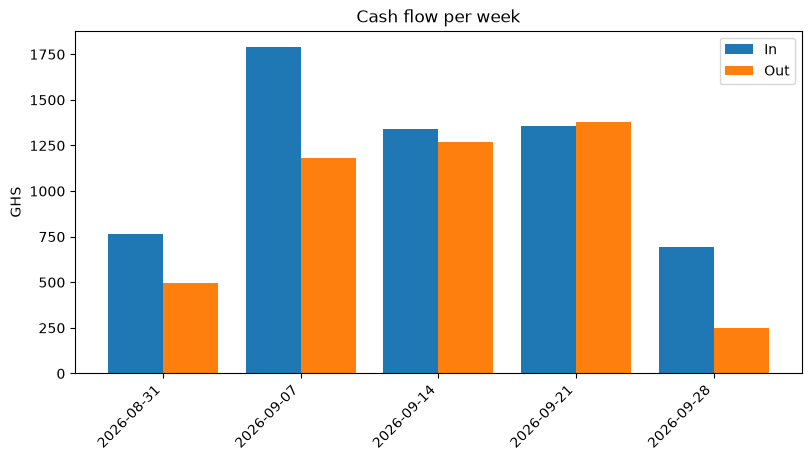

In [13]:
ledger.plot("cash_flow", period="week")

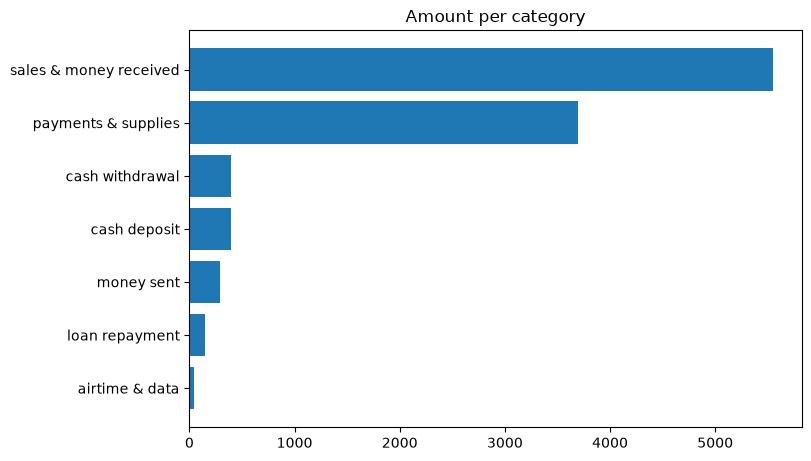

In [14]:
ledger.plot("categories")

In [15]:
ledger.export("september_ledger.xlsx")

WindowsPath('september_ledger.xlsx')

## 4. Fake payment alerts

In [16]:
genuine = messages[0]
print(fraud.check(genuine["text"], sender=genuine["sender"]))

Risk: LOW (score 0.00)
Before releasing goods or cash, confirm the payment in your official Mobile Money app or by checking your balance through your network's official USSD menu. Never rely on an SMS alone.


In [17]:
with open("../examples/suspicious.txt", encoding="utf-8") as fh:
    fake = fh.read().split("\n\n")[0]
print(fake, end="\n\n")
print(fraud.check(fake, sender="+233591234567", history=ledger.transactions))

Cash In  for
GHS150.00 from
AKOSUA MANSA OVER THE COUNTER MEDICINE SELLE. Balance 640.35
Avaliable balan 640.35
Transaction
ID: 00581234567:
depos(.....)

Risk: HIGH (score 0.99)
Reasons:
  - Sent from a personal phone number (+233 59 123 4567), not an official sender ID such as MobileMoney or T-CASH. Genuine alerts never come from personal numbers.
  - Claimed balance GHS 640.35 does not follow from your last genuine balance of GHS 187.64 (expected GHS 337.64), unless you made other transactions in between.
  - Looks like a Mobile Money alert but does not match any genuine message format.
  - Contains spelling mistakes ('Avaliable', 'balan'). Genuine alerts are machine-generated and don't have typos.
Before releasing goods or cash, confirm the payment in your official Mobile Money app or by checking your balance through your network's official USSD menu. Never rely on an SMS alone.


In [18]:
copy = messages[0]["text"]  # a perfect copy of a real alert...
print(fraud.check(copy, sender="0551234567"))  # ...sent from a personal number

Risk: HIGH (score 0.85)
Reasons:
  - Sent from a personal phone number (+233 55 123 4567), not an official sender ID such as MobileMoney or T-CASH. Genuine alerts never come from personal numbers.
Before releasing goods or cash, confirm the payment in your official Mobile Money app or by checking your balance through your network's official USSD menu. Never rely on an SMS alone.


## 5. Fees

In [19]:
print(fees.estimate("TELECEL", "send_other_network", "40", date(2026, 9, 25)))

Estimated charges for send other network of GH₵ 40.00 on TELECEL (25 Sep 2026):
  Fee: GH₵ 0.20
  Tax: GH₵ 0.00
  Total: GH₵ 0.20
Basis:
  - Fee: 1 transfer to MTN (2026) charged GHS0.20 on GHS40.00 (0.5%).
  - Tax: Repealed (Act of 2025). Consistent with 2026 Telecel messages showing "Your E-levy charge is GHS0.00".
This is an estimate. Check your network's official tariff.
